In [284]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [285]:
# import layers and combine in one dataset
ds = xr.Dataset({
    "study_area": rxr.open_rasterio('output-data/study-area/study_area.tif'),
    # predictors
    "hfp": rxr.open_rasterio('output-data/predictor-layers/hfp.tif'),
    "drainage_dist": rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif"),
    "forest_dist": rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif"),
    "pre_fire_evi": rxr.open_rasterio("output-data/predictor-layers/evi_pre.tif"),
    'aridity_index': rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif'),
    'fire_history': rxr.open_rasterio('output-data/predictor-layers/fire_count.tif'),
    'dnbr': rxr.open_rasterio('output-data/predictor-layers/dnbr.tif'),
    'elevation': rxr.open_rasterio('output-data/predictor-layers/elevation.tif'),
    # target variables
    'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017.tif"),
    'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020.tif"),
    'recovery_2y_no_neg': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017_no_neg.tif"),
    'recovery_5y_no_neg': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020_no_neg.tif"),
})

In [286]:
study_mask = ds["study_area"] == 1
output_dir = Path("figures/all_histograms")
output_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

plot_labels = {
    "hfp": "Human Footprint Index",
    "drainage_dist": "Distance to Drainage (m)",
    "forest_dist": "Distance to Forest (m)",
    "pre_fire_evi": "Pre-fire EVI",
    "aridity_index": "Aridity Index",
    "fire_history": "Fire History (count)",
    "dnbr": "dNBR",
    "elevation": "Elevation (m)",
}

plot_colors = {var: "#5ab4ac" for var in plot_labels}
legend_headroom = {
    "pre_fire_evi": 0.25,
    "aridity_index": 0.25,
    "dnbr": 0.25,
}
panel_xlabel_pad = 12

selected_predictors = [
    "hfp",
    "drainage_dist",
    "forest_dist",
    "pre_fire_evi",
    "aridity_index",
    "fire_history",
    "dnbr",
    "elevation",
]

first_group_predictors = ["hfp", "aridity_index", "fire_history", "elevation"]
second_group_predictors = ["drainage_dist", "forest_dist", "pre_fire_evi", "dnbr"]

def extract_clean_values(da, exclude_values=None):
    vals = da.where(study_mask).values.flatten().astype(float)
    nodata = da.rio.nodata
    if nodata is not None:
        vals = vals[vals != nodata]
    vals = vals[np.isfinite(vals)]
    if exclude_values is not None:
        exclude_values = np.atleast_1d(exclude_values)
        vals = vals[~np.isin(vals, exclude_values)]
    return vals

def format_hist_axes(ax):
    ax.set_axisbelow(True)
    ax.grid(True, color="#9a9a9a", alpha=0.55, linewidth=1)

    y_max = max(abs(v) for v in ax.get_ylim())

    if y_max >= 10000:
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

def add_legend_headroom(ax, var_name):
    extra_fraction = legend_headroom.get(var_name, 0)
    if extra_fraction <= 0:
        return
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * (1 + extra_fraction))

def add_panel_label(ax, panel_label):
    if panel_label is None:
        return
    ax.text(
        -0.12,
        1.03,
        panel_label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )

def add_stats_box(ax, stats_label):
    ax.text(
        0.97,
        0.95,
        stats_label,
        transform=ax.transAxes,
        fontsize=14,
        ha="right",
        va="top",
        bbox={
            "facecolor": "white",
            "edgecolor": "#bfbfbf",
            "alpha": 0.9,
            "boxstyle": "round,pad=0.3",
        },
    )

def plot_hist_on_axis(ax, vals, var_name, bins=60, color=None, panel_label=None, xlabel_pad=4):
    stats_label = f"mean: {np.mean(vals):.2f} +/- {np.std(vals):.2f}"
    sns.histplot(
        vals,
        bins=bins,
        ax=ax,
        kde=False,
        color=color or plot_colors.get(var_name, "#8fb6d8"),
        alpha=0.75,
        edgecolor=None,
        # label=stats_label,
    )
    ax.set_xlabel(plot_labels.get(var_name, var_name), labelpad=xlabel_pad)
    ax.set_ylabel("n")
    add_legend_headroom(ax, var_name)
    format_hist_axes(ax)
    add_panel_label(ax, panel_label)
    add_stats_box(ax, stats_label)
    # Re-enable if color starts encoding meaningful categories.
    # ax.legend(loc="upper right", frameon=True)

def plot_variable_histogram(var_name, title=None, color=None, bins=60, exclude_values=None, filename=None):
    vals = extract_clean_values(ds[var_name], exclude_values=exclude_values)
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_hist_on_axis(ax, vals, var_name, bins=bins, color=color, xlabel_pad=4)

    fig.tight_layout()
    output_path = output_dir / (filename or f"hist_{var_name}.png")
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

def plot_histogram_panel(var_names, filename, bins=60, panel_labels=None):
    n_cols = 2
    n_rows = int(np.ceil(len(var_names) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
    axes = np.array(axes).reshape(-1)

    if panel_labels is None:
        panel_labels = [None] * len(var_names)
    else:
        panel_labels = list(panel_labels) + [None] * max(0, len(var_names) - len(panel_labels))

    for ax, var_name, panel_label in zip(axes, var_names, panel_labels):
        vals = extract_clean_values(ds[var_name])
        plot_hist_on_axis(
            ax,
            vals,
            var_name,
            bins=bins,
            panel_label=panel_label,
            xlabel_pad=panel_xlabel_pad,
        )

    for ax in axes[len(var_names):]:
        ax.set_visible(False)

    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.12, top=0.93, wspace=0.22, hspace=0.25)
    output_path = output_dir / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

Saved: figures/all_histograms/hist_hfp.png


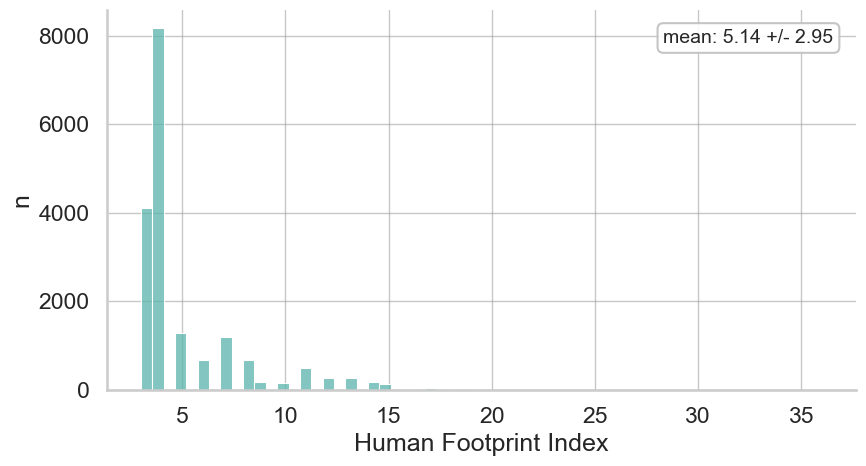

In [287]:
plot_variable_histogram(
    "hfp",
)

Saved: figures/all_histograms/hist_drainage_dist.png


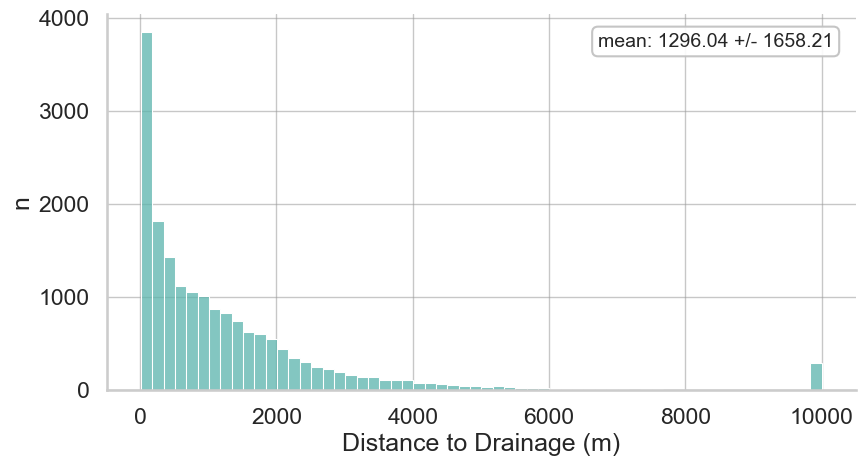

In [288]:
plot_variable_histogram(
    "drainage_dist",
)

Saved: figures/all_histograms/hist_forest_dist.png


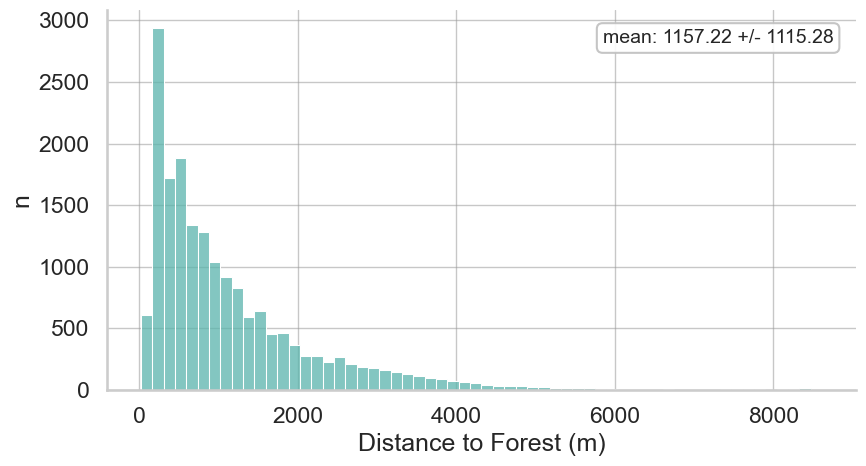

In [289]:
plot_variable_histogram(
    "forest_dist",
)

Saved: figures/all_histograms/hist_pre_fire_evi.png


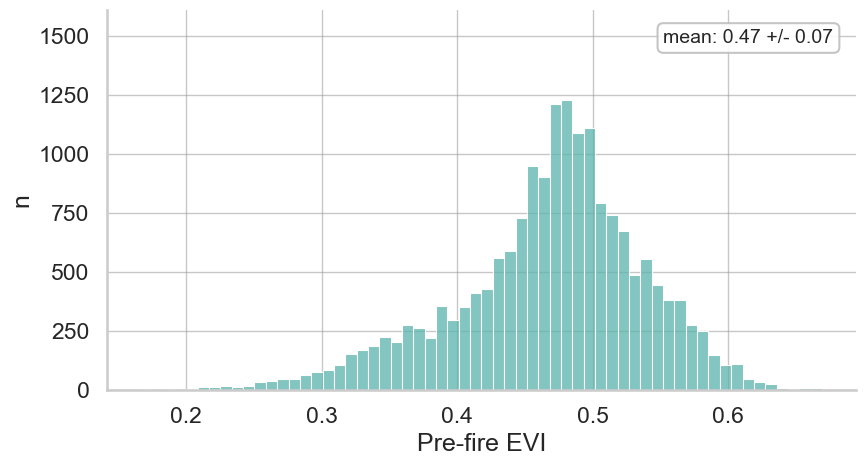

In [290]:
plot_variable_histogram(
    "pre_fire_evi"
)

Saved: figures/all_histograms/hist_aridity_index.png


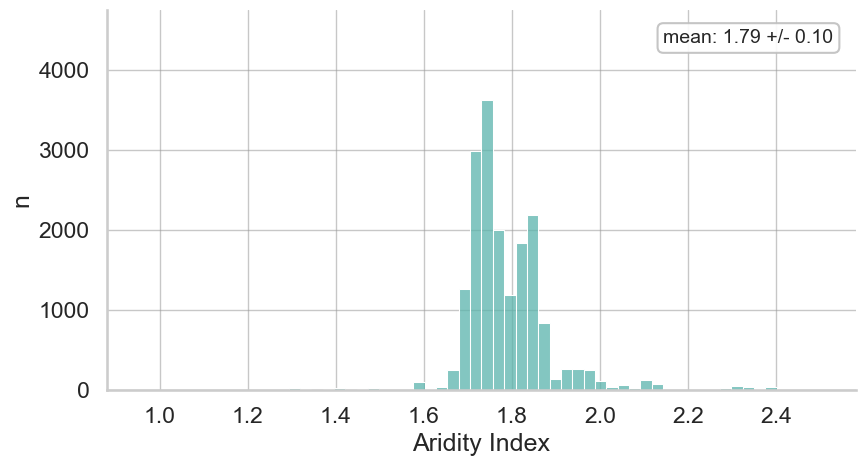

In [291]:
plot_variable_histogram(
    "aridity_index",
)

Saved: figures/all_histograms/hist_fire_history.png


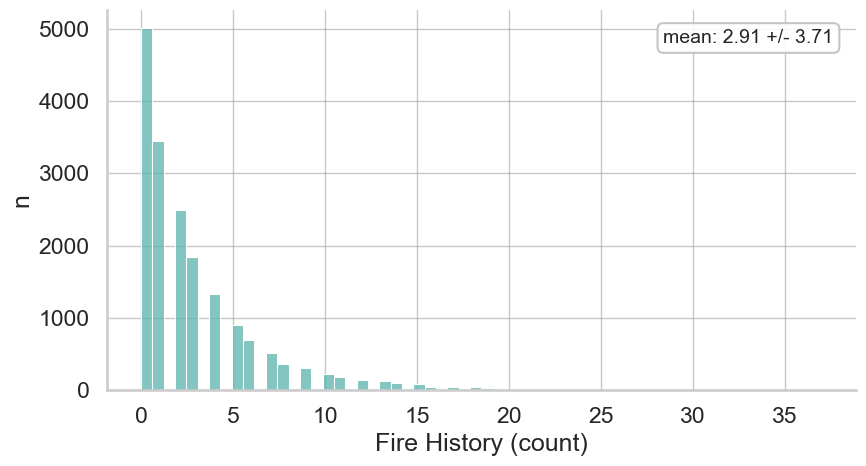

In [292]:
plot_variable_histogram(
    "fire_history"
)

Saved: figures/all_histograms/hist_dnbr.png


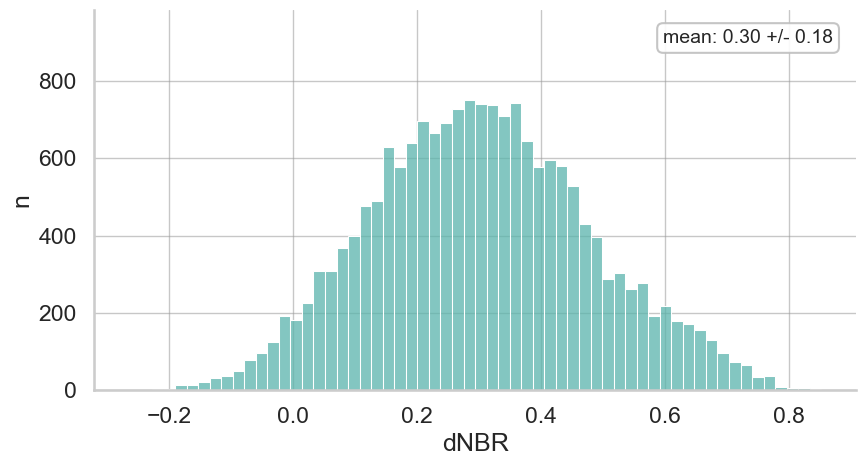

In [293]:
plot_variable_histogram(
    "dnbr",
    title="dNBR",
)

Saved: figures/all_histograms/hist_elevation.png


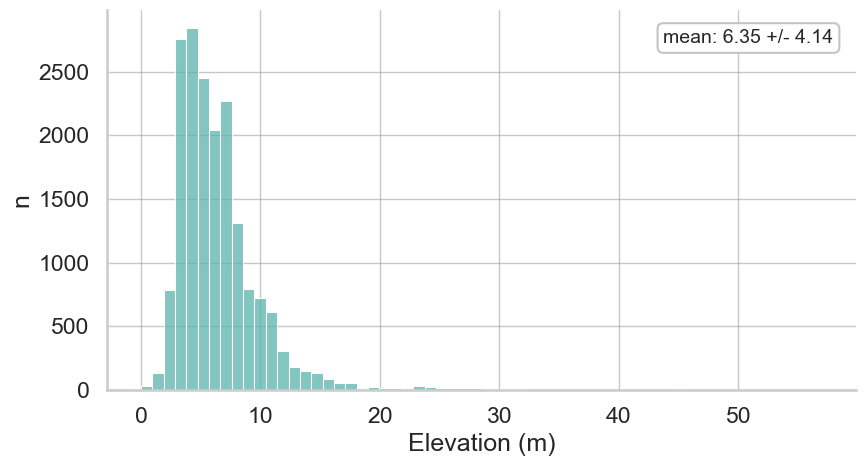

In [294]:
plot_variable_histogram(
    "elevation",
    title="Elevation",
)

Saved: figures/all_histograms/histogram_panel_pt1.png


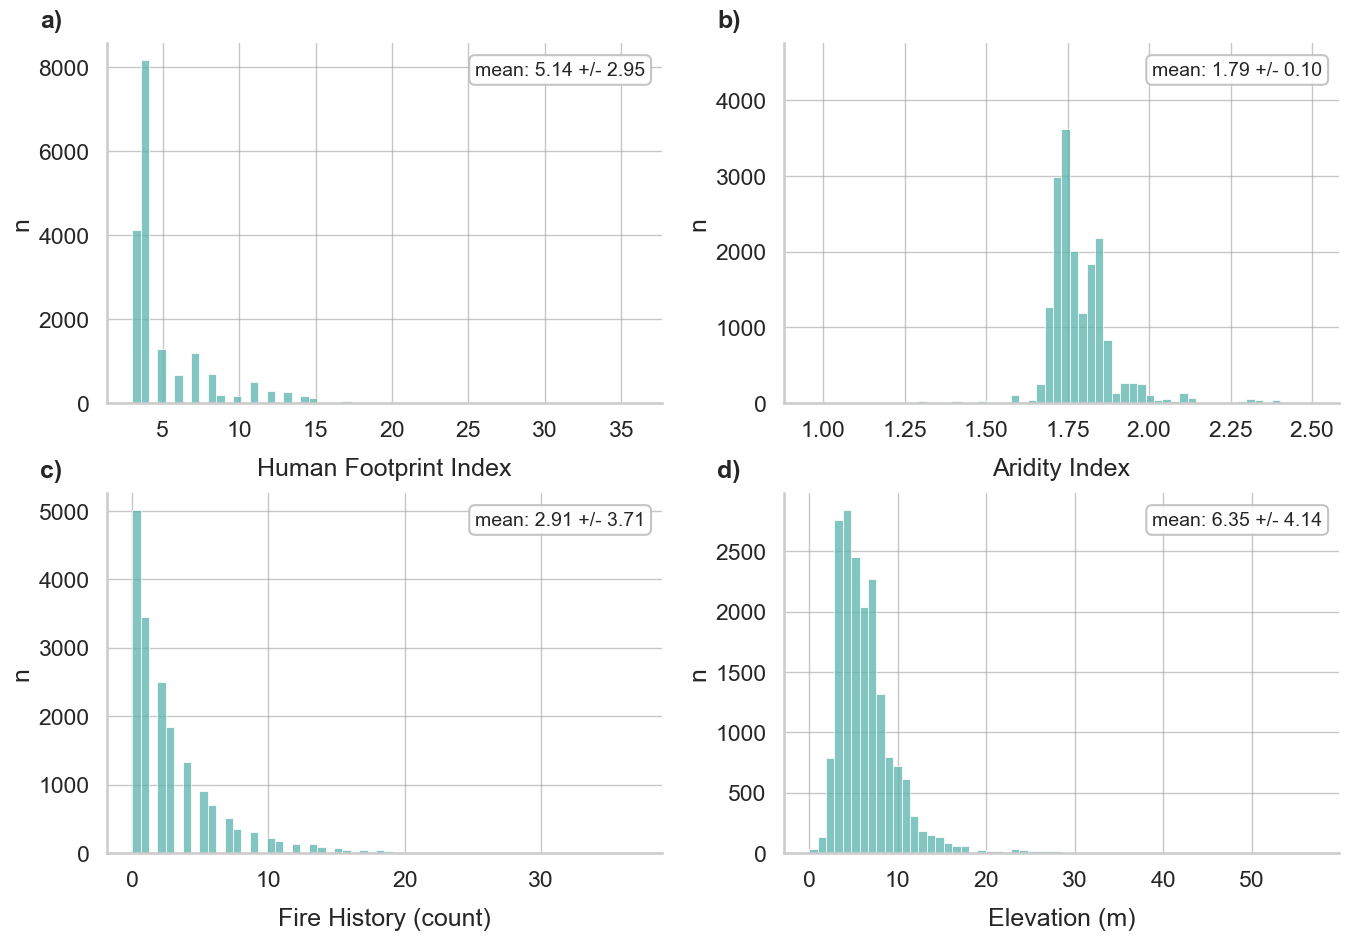

In [295]:
plot_histogram_panel(
    first_group_predictors,
    filename="histogram_panel_pt1.png",
    panel_labels=["a)", "b)", "c)", "d)"],
)

Saved: figures/all_histograms/histogram_panel_pt2.png


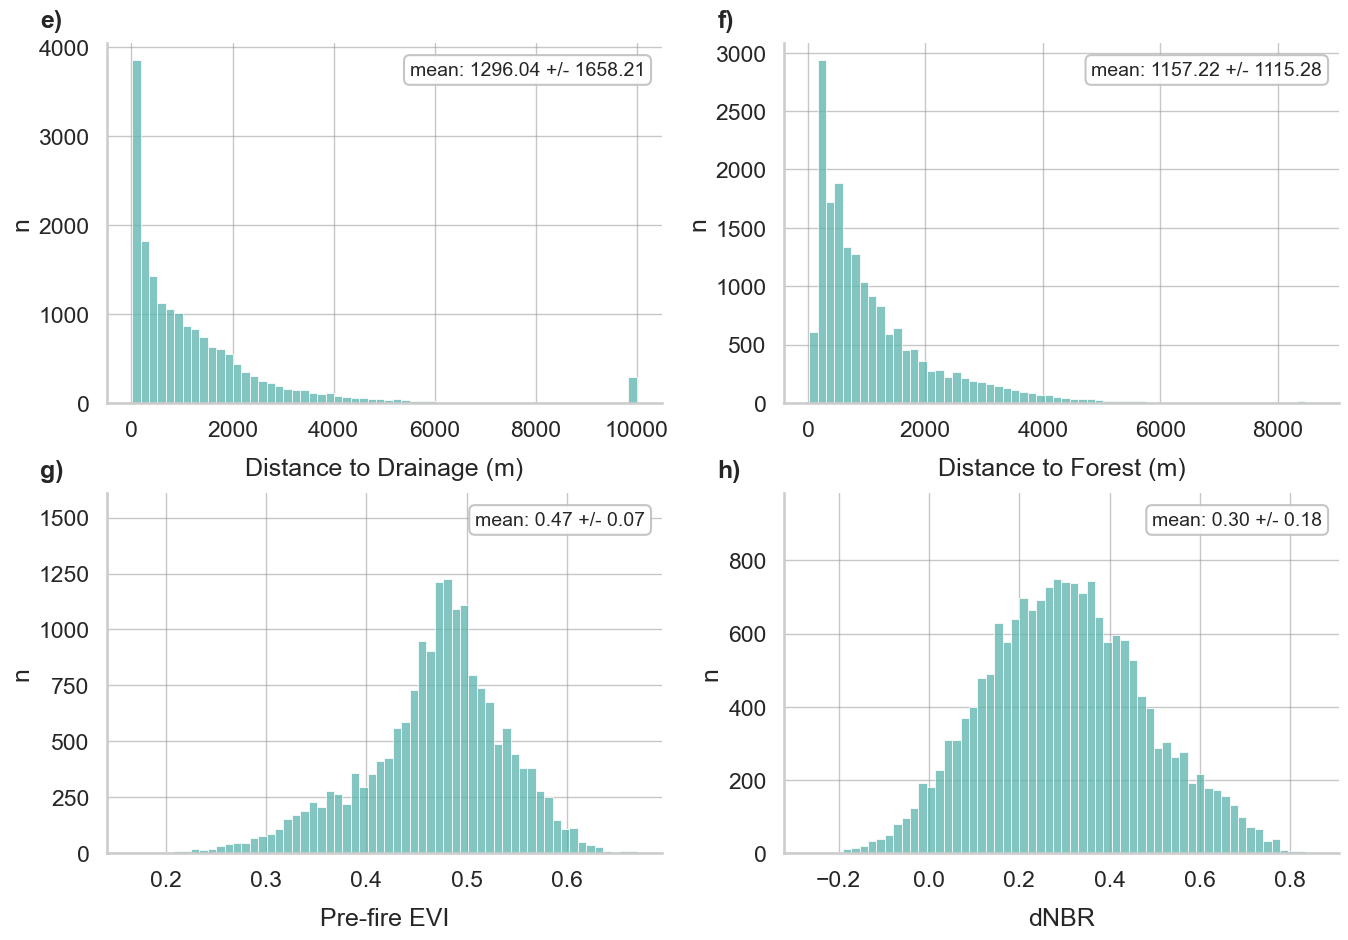

In [296]:
plot_histogram_panel(
    second_group_predictors,
    filename="histogram_panel_pt2.png",
    panel_labels=["e)", "f)", "g)", "h)"],
)